In [1]:
import matplotlib.pyplot as plt
from astroML.datasets import generate_mu_z

In [2]:
from astropy.cosmology import LambdaCDM
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neighbors import KernelDensity
from scipy.integrate import quad
import corner

In [6]:
with open('galaxyquasar.csv', 'r') as f:
    header = f.readline().strip().split(',')
    names = [header[i] for i in (0,1,2,3,4,6)]

labels=np.genfromtxt('galaxyquasar.csv', delimiter=',',skip_header=1,usecols=5,dtype=str)
data=np.genfromtxt('galaxyquasar.csv', delimiter=',',skip_header=1,usecols=(0,1,2,3,4,6),dtype=float)
d = dict(zip(names, data.T))

In [9]:
for j in ['ug', 'gr', 'ri', 'iz']:
    d[j]=d[j[0]]-d[j[1]] 
d['lab']=labels

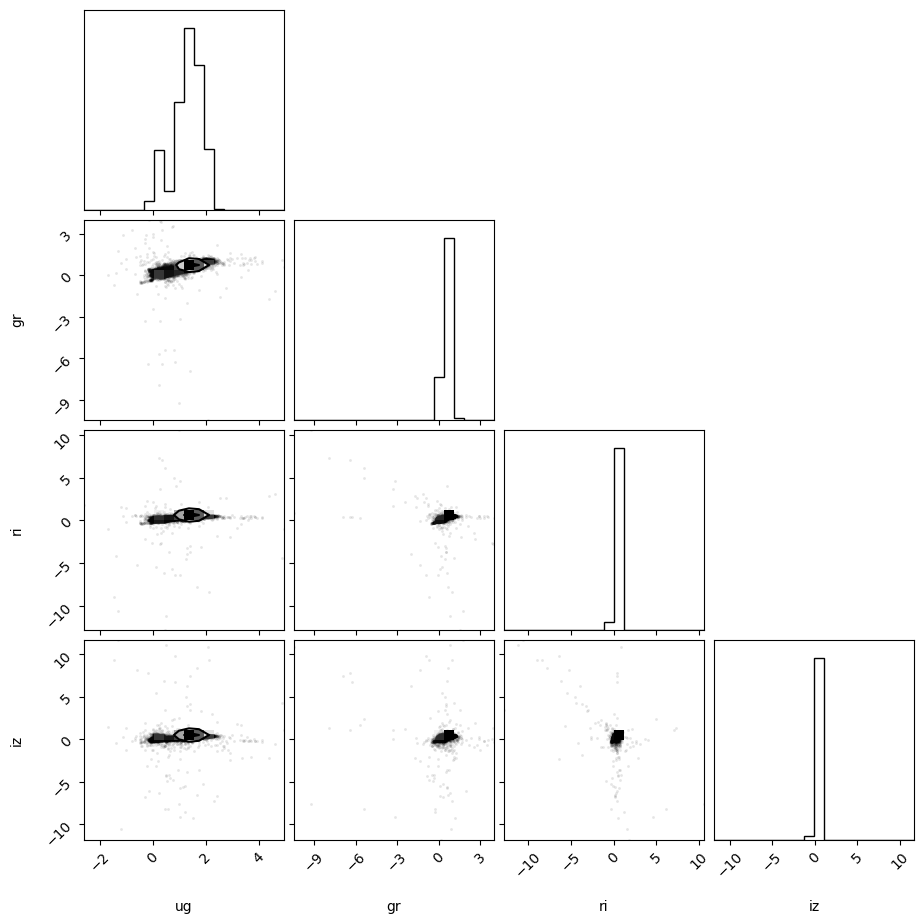

In [10]:
import corner
corner.corner(np.array([d['ug'],d['gr'],d['ri'],d['iz']]).T, labels=['ug', 'gr', 'ri', 'iz']);

In [11]:
#from this i can say that ug y gr ae nor independient, 

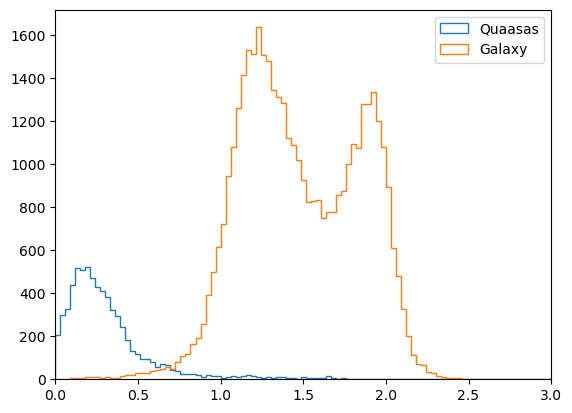

In [13]:
#about all the variables, seems to be that ug give to us a classificatino process, with the others there is no difffference.

plt.hist(d['ug'][labels=='QSO'],histtype='step',bins=np.linspace(0,3,100), label='Quaasas')
plt.hist(d['ug'][labels=='GALAXY'],histtype='step',bins=np.linspace(0,3,100), label='Galaxy')
plt.legend()
plt.xlim(0,3);

In [14]:
X = np.array([d['ug'], d['gr'], d['ri'], d['iz']]).T
y = np.array(labels=='QSO',dtype=int)

In [15]:
import sklearn.model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.30, random_state=67)

#ok entonces tenemos como X, diversos flujos, y como y tenemos el hehco de si es o no quasar, 0 e 1.... ahora espera, esto tiene multiples entrada X , digamos clases? hay  clases y hay diversos flujos.

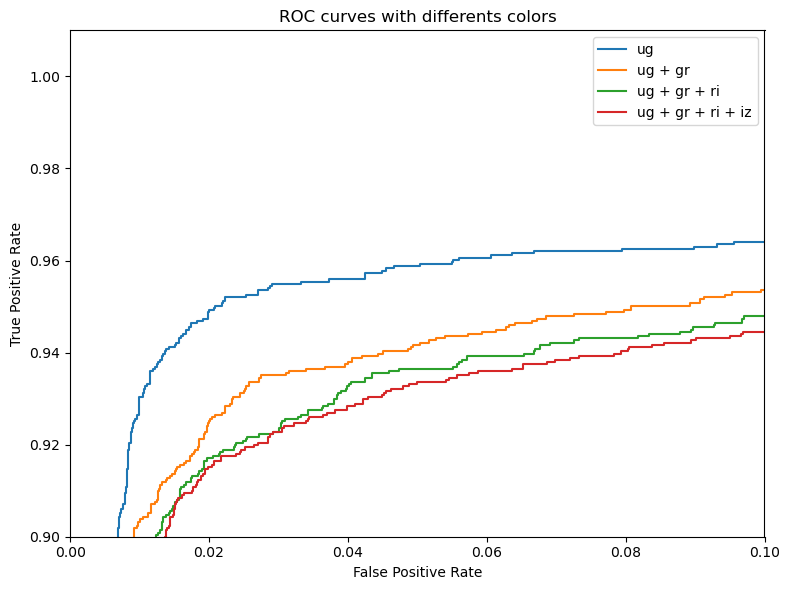

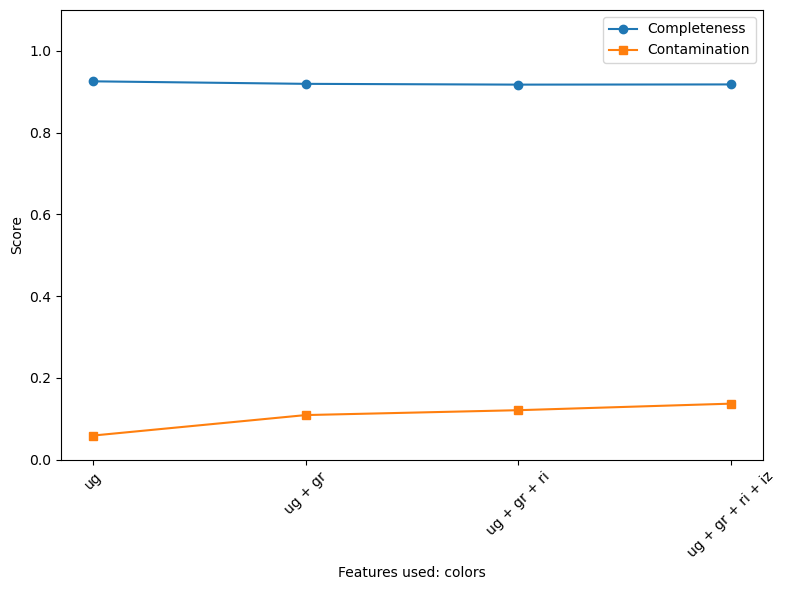

In [37]:
from astroML.utils import completeness_contamination

clf = GaussianNB()

color_names = ['ug', 'gr', 'ri', 'iz']
labels = []
X_features = []

for i in range(4):
    labels.append(" + ".join(color_names[:i+1]))
    X_features.append(X_train[:, :i+1])

plt.figure(figsize=(8,6))

predictions=[]
for i in range(4):
    clf.fit(X_features[i], y_train)
    y_prob = clf.predict_proba(X_test[:, :i+1])[:, 1]
    y_pred = clf.predict(X_test[:, :i+1])
    predictions.append(y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    label_text = f"{labels[i]}"
    plt.plot(fpr, tpr, label=label_text)

completeness, contamination = completeness_contamination(predictions, y_test)
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves with differents colors")
plt.xlim(0, 0.1)
plt.ylim(0.9, 1.01)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

x = np.arange(len(labels))

plt.plot(x, completeness, marker='o', label='Completeness')
plt.plot(x, contamination, marker='s', label='Contamination')

plt.xticks(x, labels, rotation=45)
plt.ylim(0, 1.1)
plt.xlabel("Features used: colors")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# i can not undertand this beheavor

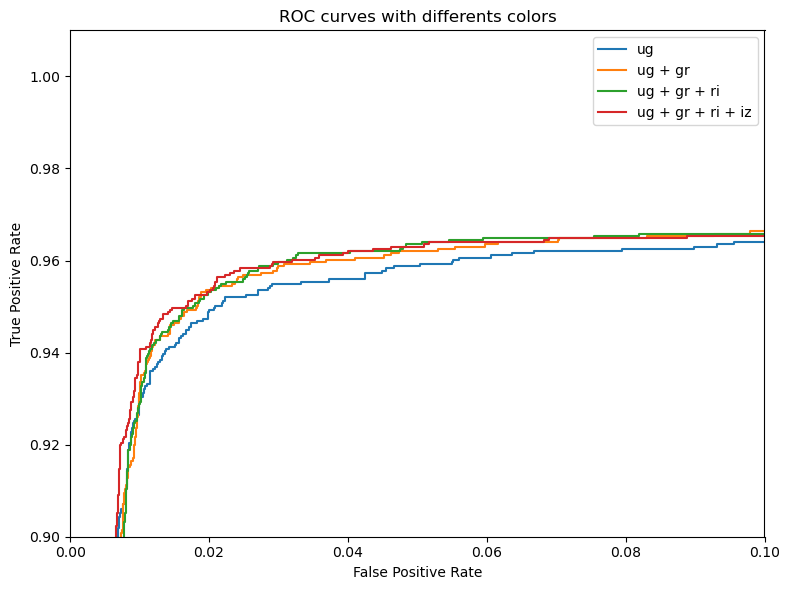

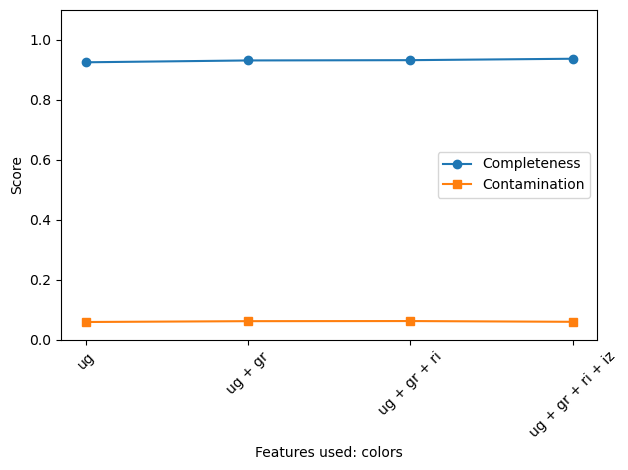

In [41]:
clf = QuadraticDiscriminantAnalysis()

plt.figure(figsize=(8,6))
predictions=[]

for i in range(4):
    clf.fit(X_features[i], y_train)
    y_prob = clf.predict_proba(X_test[:, :i+1])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    y_pred = clf.predict(X_test[:, :i+1])
    predictions.append(y_pred)
    #roc_auc = auc(fpr, tpr)
    label_text = f"{labels[i]}"
    plt.plot(fpr, tpr, label=label_text)

plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves with differents colors")
plt.xlim(0, 0.1)
plt.ylim(0.9, 1.01)
plt.tight_layout()
plt.show()

completeness, contamination = completeness_contamination(predictions, y_test)
plt.plot(x, completeness, marker='o', label='Completeness')
plt.plot(x, contamination, marker='s', label='Contamination')

plt.xticks(x, labels, rotation=45)
plt.ylim(0, 1.1)
plt.xlabel("Features used: colors")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#from here instead you are learning more if you use more colors, becouse if you only use the first you have more contamination ans less completeness, maybe bc evry time you are addong new info there is not a dependenci with the already put there so..

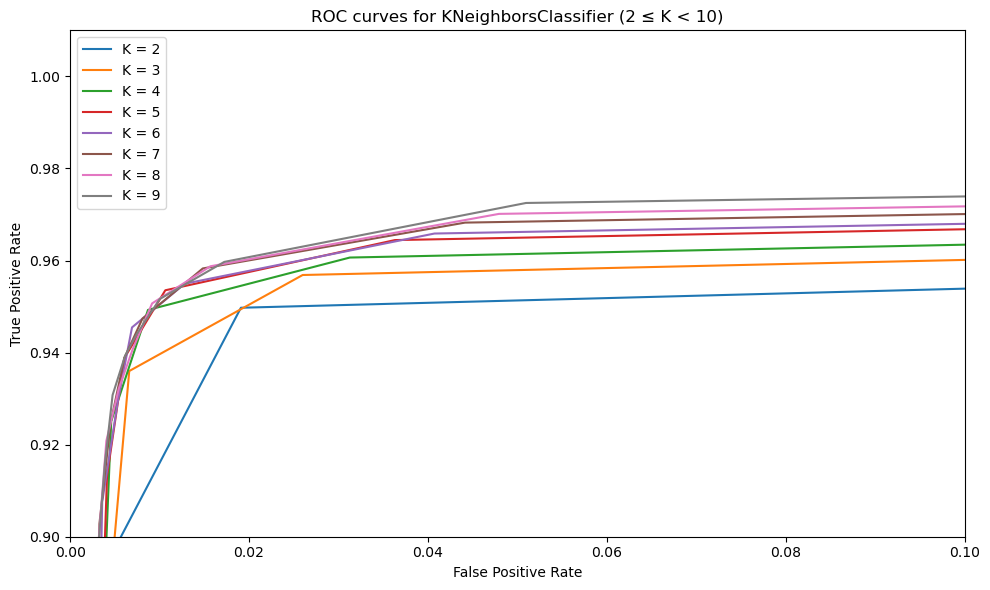

In [194]:
plt.figure(figsize=(10, 6))

for n in np.arange(2, 10):
    clf = KNeighborsClassifier(n_neighbors=n)
    clf.fit(X_train[:, :4], y_train)
    y_prob = clf.predict_proba(X_test[:, :4])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"K = {n}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves for KNeighborsClassifier (2 ≤ K < 10)")
plt.legend()
plt.xlim(0, 0.1)
plt.ylim(0.9, 1.01)
plt.tight_layout()
plt.show()

In [44]:
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier() #model 

param_grid = {
    'n_neighbors': np.arange(2, 9)
}

scorer = make_scorer(roc_auc_score, needs_proba=True)
grid_search = GridSearchCV(knn, param_grid, scoring=scorer, cv=5)
grid_search.fit(X_train[:, :4], y_train)
print("Best K:", grid_search.best_params_['n_neighbors'])
print("Best AUC (cv):", grid_search.best_score_)

Best K: 8
Best AUC (cv): 0.9841478844310556


In [195]:
#next step is do a CV for k number, and then the other classifiar you will need it as well, idk why but ok

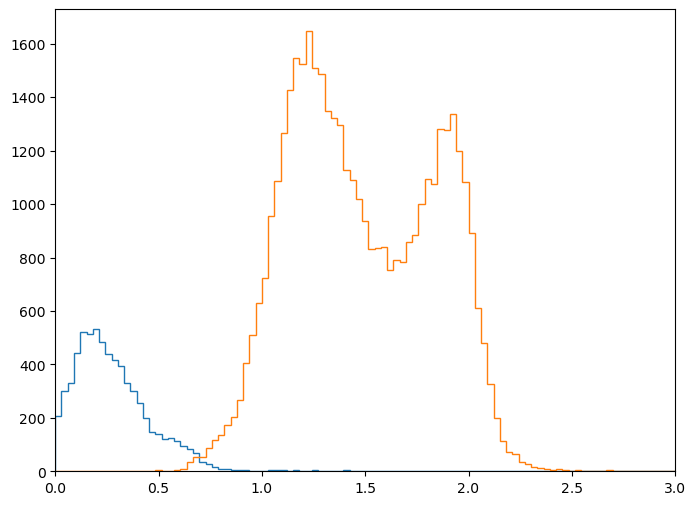

In [201]:
#how good is on classified , differencia entre predic_proba and predic? well we need predcit for this and it also uses X not only the validation sot,o ok i guess i got it

clf = QuadraticDiscriminantAnalysis()

plt.figure(figsize=(8,6))

clf.fit(X_features[3], y_train)
y_pred = clf.predict(X[:, 0:4])

plt.hist(d['ug'][y_pred==1],histtype='step',bins=np.linspace(0,3,100))
plt.hist(d['ug'][y_pred==0],histtype='step',bins=np.linspace(0,3,100))
plt.xlim(0,3)
plt.show();

In [149]:
from sklearn.mixture import GaussianMixture

class GMMBayesReplacement:
    def __init__(self, n_components=1):
        self.n_components = n_components
        self.models = {}
        self.classes = []

    def fit(self, X, y):
        self.classes = np.unique(y)
        for cls in self.classes:
            gmm = GaussianMixture(n_components=self.n_components, random_state=0)
            gmm.fit(X[y == cls])
            self.models[cls] = gmm

    def predict(self, X):
        log_probs = np.array([self.models[cls].score_samples(X) for cls in self.classes]).T
        return self.classes[np.argmax(log_probs, axis=1)]

(0.9, 1.0)

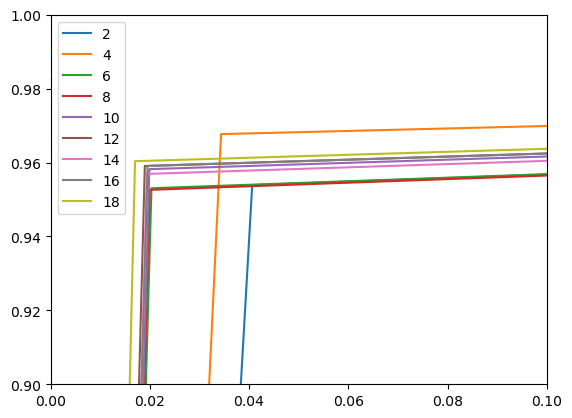

In [151]:
for n in np.arange(2,20)[::2]:
    
    clf = GMMBayesReplacement(n_components=n)
    clf.fit(X_train[:,0:4],y_train)
    
    y_prob = clf.predict(X_test[:,0:4])
        
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(n))

plt.legend()
plt.xlim(0,0.1)
plt.ylim(0.9,1)

In [152]:
# fianlly no se peude comrpar porque el GMMBayes no ahce lo mismo